## [통계적 검정과 인과추론] - A/B 테스트
### 주제 : 유료광고(cpc) vs 자연검색(organic) 유입 유저의 구매 전환율 비교 — 유료광고는 실제로 효과가 있는가?
### 작성자 : 한서연
### 작성일 : 2026.07.31
---
### 데이터셋설명
1. 이름 :  GA4 Obfuscated Sample E-commerce Dataset
2. 출처 : 구글이 운영하는 실제 온라인 쇼핑몰(Google Merchandise Store)의 방문 로그
3. 특징
 - "obfuscated"(난독화됨)라는 이름처럼, 개인정보는 익명 처리되어 있지만 행동 패턴 자체는 실제 사용자 데이터
 - 날짜별로 테이블이 쪼개져 있고 (events_20201101처럼), 한 행(row)이 "이벤트 1건"을 의미함
 - `event_name`(무슨 행동을 했는지: page_view, purchase 등), `event_params`(그 행동의 세부정보, 중첩 구조)로 구성됨
 - A/B 그룹이 원래 없음. 기기 종류나 유입 경로 같은 기존 속성으로 직접 두 그룹을 나눠서 비교해야 하는 구조
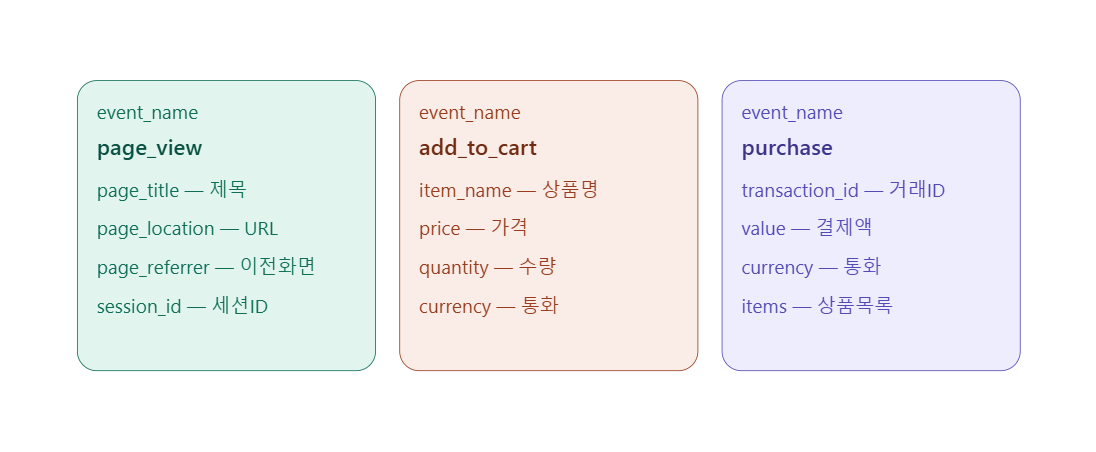 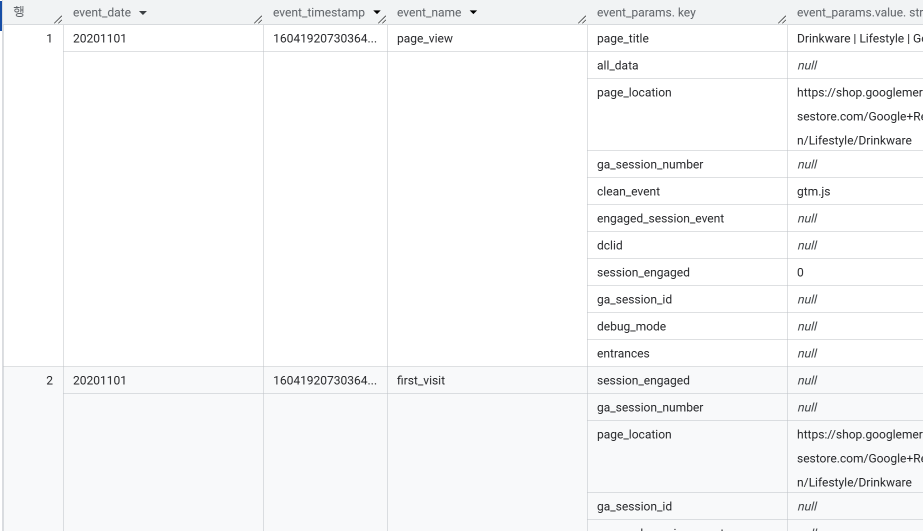


### 데이터 선택 이유
 - 퍼포먼스 마케터를 목표로 하고 있어서, "GA4 형식의 실제 웹 로그 데이터를 SQL로 직접 다뤄보는 경험"이  도움이 될 것 같다는 판단
  - BigQuery에는 구글이 공개해둔 여러 퍼블릭 데이터셋이 있는데, 그중 GA4 형식으로 된 이커머스 데이터가 마케팅/전환 분석과 가장 밀접해서 첫 후보로 골랐던 것

---

### 1. 데이터 위생 점검
    ! 147만 건짜리 원본 로그 데이터를 통째로 파이썬(pandas)으로 다운받으면 너무 크고 느림
    따라서 BigQuery 안에서 SQL로 필요한 만큼만 미리 요약/집계해서 작은 표로 만든 다음, 그 결과만 CSV로 내려받는 것으로 계획

- **기본 확인** — 행 수, 컬럼, 자료형, 결측치
    - 전체 행 수: 1,472,712건 (중첩구조)
    - 핵심 컬럼 결측치: 없음
    - 데이터 기간: 20201101 - 20201130 (총 30일)

- **중복 확인** — 같은 사용자 ID가 두 번 이상 등장하는가?
    - 한 행 = "이벤트 1건"이라서, 같은 `user_pseudo_id`가 수십~수백 번 나오는 게 지극히 정상
    - 위와 같은 이유로 `user_pseudo_id` + `event_timestamp` + `event_name`이 셋 다 완전히 똑같은 행이 중복인 결과만 확인
    - 쿼리 실행 결과 빈 테이블 -> 완전 중복 데이터 없음

In [1]:
# 데이터 가져오기 
# SELECT *
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20201101`
# LIMIT 10

# 데이터 칼럼 및 타입 살펴보기 (11월 1일 하루치)
# SELECT column_name, data_type
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.INFORMATION_SCHEMA.COLUMNS`
# WHERE table_name = 'events_20201101'

# 11월 전체 데이터 가져오기
# SELECT COUNT(*) AS total_rows
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
# WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'

# 결측치 확인
# SELECT
#  COUNTIF(event_name IS NULL) AS null_event_name,
#  COUNTIF(device.category IS NULL) AS null_device_category,
#  COUNTIF(user_pseudo_id IS NULL) AS null_user_id
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
# WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'

# 데이터 날짜 확인
# SELECT
#   MIN(event_date) AS start_date,
#   MAX(event_date) AS end_date,
#  COUNT(DISTINCT event_date) AS num_days
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
# WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'

# 데이터 완전 중복(같은 유저(user_pseudo_id) + 같은 시각(event_timestamp) + 같은 이벤트(event_name)) 확인 
# SELECT
#   user_pseudo_id,
#   event_timestamp,
#   event_name,
#   COUNT(*) AS cnt
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
# WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
# GROUP BY user_pseudo_id, event_timestamp, event_name
# HAVING COUNT(*) > 1
# ORDER BY cnt DESC
# LIMIT 20

# traffic_source 안에 있는 값들 확인 (유입경로 확인)
# SELECT
#   traffic_source.medium,
#   COUNT(DISTINCT user_pseudo_id) AS user_count
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
# WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
# GROUP BY traffic_source.medium
# ORDER BY user_count DESC
# ------------------------------------------------------
# 행    medium    user_count
# 1    organic    32975
# 2    (none)    22795
# 3    referral    17356
# 4    <Other>    14653
# 5    (data deleted)    6729
# 6    cpc    4421

### 2. 질문과 가설 정하기 

traffic_source 쿼리를 돌려본 결과, (data deleted), <Other>, (none) 같은 애매한 카테고리들이 섞여서 전체 그림이 지저분해 보임. 따라서 전체 유저 중, medium이 딱 cpc(유료광고)이거나 organic(자연검색)인 유저들만 골라서 그 안에서 비교하기로 결정
| 순위 | medium | user_count |
|---|---|---|
| 1 | organic | 32,975 |
| 2 | (none) | 22,795 |
| 3 | referral | 17,356 |
| 4 | `<Other>` | 14,653 |
| 5 | (data deleted) | 6,729 |
| 6 | cpc | 4,421 |

- 귀무가설 $H_0$ : **유료광고 유입 유저와 자연검색 유입 유저의 구매 전환율은 차이가 없다**
- 대립가설 $H_1$ : **유료광고 유입 유저와 자연검색 유입 유저의 구매 전환율은 차이가 있다**
-  유의수준 $\alpha$ = 0.05 , **양측**을 결정합니다.
    - 유료광고가 정말 효과가 있는지 알아보는 탐색적 분석 단계라, cpc가 organic보다 낮게 나올 가능성도 열어두고 보기 위해 양측 검정 실시


- **배정 일관성** — 처치 라벨이 서로 어긋난 행은 없는가?
    - 쿼리 실핼 결과 50행 확인 (같은 사람이 어느 날은 광고 클릭해서 들어오고, 다른 날은 검색해서 들어온 것)
    - cpc 전체(4,421명) 대비: 496 / 4,421 ≈ 11.2% (적지 않다고 판단)
    - organic 전체(32,975명) 대비: 496 / 32,975 ≈ 1.5%
    - 이미 cpc 표본이 적기 때문에 표본 크기를 보호하기 위하여 마지막 접촉 기준으로 배정
    - 근거 : 결국 최종적으로 구매 결정을 내리게 만든 게 어떤 채널이었나를 보는 관점으로 마케팅 예산을 어디에 더 투자할지 결정할 때, 실무에서 가장 널리 쓰이는 기준
    - 최종 결과 : organic = 32,818 / cpc = 	4,082
- **SRM 점검** — 배정 비율이 의도대로인가?
    - 이번 분석은 회사가 의도적으로 배정한 실험이 아니라, 유저가 자연적으로 선택한 유입경로를 사후적으로 비교하는 관찰연구 형태다.
    - **한계** : cpc와 organic 유입 유저 간 발견된 차이는 인과관계가 아닌 상관관계로 해석해야 한다. 두 집단은 애초에 관심도, 구매 의도 등에서 차이가 있을 수 있는 자기선택 편향의 가능성을 배제할 수 없다.

In [2]:
# 배정 일관성 체크
# SELECT
#  user_pseudo_id,
#  COUNT(DISTINCT traffic_source.medium) AS medium_count
# FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
# WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
#   AND traffic_source.medium IN ('cpc', 'organic')
# GROUP BY user_pseudo_id
# HAVING medium_count > 1
# ----
# 1    2330556.9474606268    2
# 2    4011278.0806177422    2
# 3    4906095.9206867835    2
# 4    5121207.0168898371    2
# .
# .

# cpc(4,421명) 또는 organic(32,975명) 전체 대비 몇 %가 겹치는지 계산
# SELECT COUNT(DISTINCT user_pseudo_id) AS overlapping_users
# FROM (
#   SELECT
#     user_pseudo_id,
#     COUNT(DISTINCT traffic_source.medium) AS medium_count
#   FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
#   WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
#    AND traffic_source.medium IN ('cpc', 'organic')
#   GROUP BY user_pseudo_id
#   HAVING medium_count > 1
# )

# 각 유저의 가장 최근 이벤트 시각(event_timestamp)의 medium 값을 찾아서 그걸 그 유저의 최종 그룹으로 지정
# WITH last_touch AS (
#   SELECT
#     user_pseudo_id,
#     traffic_source.medium AS medium,
#     ROW_NUMBER() OVER (
#       PARTITION BY user_pseudo_id 
#       ORDER BY event_timestamp DESC
#     ) AS rn
#   FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
#   WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
#     AND traffic_source.medium IN ('cpc', 'organic')
# )
# SELECT
#   medium,
#   COUNT(*) AS user_count
# FROM last_touch
# WHERE rn = 1
# GROUP BY medium

# (구매 이벤트)를 한 번이라도 남긴 유저 목록을 뽑고 그룹별 전체 유저수와, 그중 구매까지 한 유저수를 같이 세기
# user_purchase AS (
#   SELECT DISTINCT user_pseudo_id
#   FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
#   WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
#     AND event_name = 'purchase'
# )
# SELECT
#   g.medium,
#   COUNT(DISTINCT g.user_pseudo_id) AS total_users,
#   COUNT(DISTINCT p.user_pseudo_id) AS purchasers
# FROM user_group g
# LEFT JOIN user_purchase p
#   ON g.user_pseudo_id = p.user_pseudo_id
# GROUP BY g.medium

**최종 데이터**
|  | 구매 | 비구매 | 종합
|---|---|---|---|
| cpc | 85 | 3,997 | 4,082 |
| organic | 799 | 32,019 | 32,818 |

### 3. 검정 고르기 
- 이번 분석의 성공지표는 "구매 여부"(했다/안했다)로, 비율형 지표입니다. 비교할 집단은 cpc, organic 두 개임.
- 비율 지표 + 2집단 비교 조건에 해당하므로, 카이제곱 독립성 검정을 사용했음.

### 4. 검정 수행하고 3종 세트로 보고
- 점추정 (차이)	얼마나 차이 나는가
- 95% 신뢰구간	그 추정이 얼마나 불확실한가
- 효과 크기	그 차이가 큰 차이인가

In [6]:
# 점추정 (전환율 차이)
organic_rate = 799 / 32818
cpc_rate = 85 / 4082

diff = organic_rate - cpc_rate

print(f"organic 전환율: {organic_rate:.4%}")
print(f"cpc 전환율: {cpc_rate:.4%}")
print(f"전환율 차이(%p): {diff:.4%}")

# 95% 신뢰구간 (두 비율 차이의 신뢰구간)
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_upp = confint_proportions_2indep(
    count1=799, nobs1=32818,
    count2=85, nobs2=4082,
    method='wald'
)

print()
print(f"전환율 차이의 95% 신뢰구간: [{ci_low:.4%}, {ci_upp:.4%}]")

# 효과크기 (Cramér's V)

# 데이터 입력
organic_purchase, organic_total = 799, 32818
cpc_purchase, cpc_total = 85, 4082

from scipy.stats import chi2_contingency
import numpy as np

# 전환율 계산
organic_rate = organic_purchase / organic_total
cpc_rate = cpc_purchase / cpc_total

# ① 절대 차이 (%p)
absolute_diff = (organic_rate - cpc_rate) * 100

# ② 상대 차이 (배수)
relative_diff = organic_rate / cpc_rate

# ③ 카이제곱 검정
table = np.array([
    [organic_purchase, organic_total - organic_purchase],
    [cpc_purchase, cpc_total - cpc_purchase]
])
chi2, p, dof, expected = chi2_contingency(table, correction=False)

# ④ 효과크기 (Cramér's V)
n = table.sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

# 결과 출력
print()
print(f"organic 전환율: {organic_rate:.2%}, cpc 전환율: {cpc_rate:.2%}")
print(f"절대 차이: {absolute_diff:+.2f}%p")
print(f"상대 차이: {relative_diff:.2f}배")
print(f"χ²({dof}) = {chi2:.2f}, p = {p:.3f}, Cramér's V = {cramers_v:.2f}")
print()
print("organic 유입 유저의 전환율(2.43%)이 cpc 유입 유저(2.08%)보다 다소 높게 나타났으나(+0.35%p, 상대적으로 1.17배),")
print("이 차이는 통계적으로 유의미하지 않았다(χ²(1) = 1.93, p = 0.165, Cramér's V = 0.01). 95% 신뢰구간이 0을 포함하고 있어, ")
print("두 유입 경로 간 전환율에 실질적인 차이가 있다고 보기는 어렵다.")

organic 전환율: 2.4346%
cpc 전환율: 2.0823%
전환율 차이(%p): 0.3523%

전환율 차이의 95% 신뢰구간: [-0.1164%, 0.8210%]

organic 전환율: 2.43%, cpc 전환율: 2.08%
절대 차이: +0.35%p
상대 차이: 1.17배
χ²(1) = 1.93, p = 0.165, Cramér's V = 0.01

organic 유입 유저의 전환율(2.43%)이 cpc 유입 유저(2.08%)보다 다소 높게 나타났으나(+0.35%p, 상대적으로 1.17배),
이 차이는 통계적으로 유의미하지 않았다(χ²(1) = 1.93, p = 0.165, Cramér's V = 0.01). 95% 신뢰구간이 0을 포함하고 있어, 
두 유입 경로 간 전환율에 실질적인 차이가 있다고 보기는 어렵다.


### 5️. 한 걸음 더 · 아래 중 1개 선택
- **Q1. 이 실험은 효과를 잡을 ’힘’이 있었나**
    - 80% 검정력으로 +1%p를 잡으려면 그룹당 몇 명이 필요한가?
    - MDE — 지금 표본으로 잡을 수 있는 가장 작은 효과는? 
- A. : 
    - 80% 검정력으로 +1%p 차이를 잡으려면 그룹당 약 3,912명이 필요했으나, 실제 cpc 그룹 표본(4,082명)은 이보다 많아 이 조건은 충족했다. 
    - 다만 우리 표본이 감지할 수 있는 최소 효과(MDE)는 0.72%p였는데, 실제 관찰된 차이(0.35%p)는 이보다 작았다. 
    - 즉 이번 분석에서 유의한 차이를 발견하지 못한 것은 "진짜 차이가 없다"는 것일 수도 있지만, "0.35%p라는 차이가 진짜인지 우연인지 확신할 수 있을 만큼 우리 표본이 정밀하지 않았다"는 가능성도 배제할 수 없다.

- **Q2. 그럼 우리는 어떻게 해야 하는가**
    - 만약 표본을 더 늘리면 어떻게 되는가?
- A. : 
    - 표본을 늘렸는데도 계속 비슷하게 0.3~0.4%p 근처로 나온다 → 이건 아마 진짜 존재하는 작은 차이일 가능성이 높다. (표본을 늘리면 이 정도 작은 차이도 유의하게 나올 거예요)
    - 표본을 늘렸더니 차이가 0%p 근처로 줄어들거나 방향이 바뀐다 → 애초에 4,082명 표본에서 나온 0.35%p는 우연한 흔들림이었다는 뜻

In [4]:
# 80% 검정력으로 +1%p 차이를 잡으려면 그룹당 몇 명이 필요한가?

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

analysis = NormalIndPower()

# 기준 전환율(cpc)에서 +1%p 올랐을 때의 효과크기 계산
baseline_rate = cpc_rate
target_rate = cpc_rate + 0.01  # +1%p

effect_size_1pp = proportion_effectsize(target_rate, baseline_rate)

# 그룹당 필요한 표본 수 계산 (두 그룹 동일 비율 가정)
required_n = analysis.solve_power(
    effect_size=effect_size_1pp,
    alpha=0.05,
    power=0.8,
    ratio=1,
    alternative='two-sided'
)

print(f"+1%p 차이를 80% 검정력으로 잡으려면, 그룹당 필요한 표본 수: {required_n:.0f}명")

+1%p 차이를 80% 검정력으로 잡으려면, 그룹당 필요한 표본 수: 3912명


In [5]:
# MDE — 지금 표본(cpc 4,082명)으로 잡을 수 있는 가장 작은 효과는?

# effect_size를 비워두고, 현재 표본 수(nobs1)를 넣어서 역산
mde_effect_size = analysis.solve_power(
    nobs1=cpc_total,
    alpha=0.05,
    power=0.8,
    ratio=organic_total / cpc_total,
    alternative='two-sided'
)

# Cohen's h를 %p 단위로 환산
import numpy as np

def h_to_p2(p1, h):
    phi1 = 2 * np.arcsin(np.sqrt(p1))
    phi2 = phi1 + h
    return np.sin(phi2 / 2) ** 2

mde_rate = h_to_p2(cpc_rate, mde_effect_size)
mde_pp = (mde_rate - cpc_rate) * 100

print(f"우리 표본으로 80% 검정력에서 잡을 수 있는 최소 효과(MDE): {mde_pp:.2f}%p")

우리 표본으로 80% 검정력에서 잡을 수 있는 최소 효과(MDE): 0.72%p


## 6. 의사결정 마무리

### 1. 질문과 가설

**분석 질문**: 유료광고(cpc) 유입 유저와 자연검색(organic) 유입 유저 간, 구매 전환율에 차이가 있는가? — 유료광고는 실제로 효과가 있는가?

- H0 (귀무가설): cpc 유입 유저와 organic 유입 유저의 구매 전환율은 차이가 없다
- H1 (대립가설): cpc 유입 유저와 organic 유입 유저의 구매 전환율은 차이가 있다
- 유의수준: α = 0.05, 양측검정

### 2. 데이터 위생 점검

- 데이터: BigQuery `ga4_obfuscated_sample_ecommerce` (2020년 11월, 총 1,472,712건 이벤트)
- 핵심 컬럼(event_name, device.category, user_pseudo_id) 결측치: 없음
- 완전 중복 이벤트: 없음
- **배정 일관성 이슈 발견**: 동일 유저가 cpc·organic 양쪽에서 관측된 경우 496명 확인 (cpc 대비 약 11.2%)
  → 라스트터치(last-touch) 기준으로 유저별 최종 유입경로를 재정의하여 해결
- 최종 표본: organic 32,818명, cpc 4,082명
- SRM은 본 데이터가 무작위 배정이 아닌 관찰 데이터이므로 해당 없음 (한계 항목에서 재언급)

### 3. 검정 선택 근거

성공지표는 "구매 여부"(했다/안했다)로 비율형 지표이며, 비교 집단은 cpc, organic 2개이다. 비율 지표 + 2집단 비교 조건에 해당하므로 **카이제곱 독립성 검정**을 사용하였다.

### 4. 결과

| 항목 | 값 |
|---|---|
| organic 전환율 | 2.43% |
| cpc 전환율 | 2.08% |
| 절대 차이 | +0.35%p |
| 상대 차이 | 1.17배 |
| 95% 신뢰구간 | [-0.12%p, 0.82%p] |
| χ²(1) | 1.93 |
| p-value | 0.165 |
| Cramér's V | 0.01 |

organic 유입 유저의 전환율이 cpc 유입 유저보다 다소 높게 나타났으나, 이 차이는 통계적으로 유의미하지 않았다(p = 0.165). 신뢰구간이 0을 포함하고 있으며, 효과크기(Cramér's V = 0.01) 또한 매우 작았다.

**검정력/MDE 분석**: 80% 검정력으로 +1%p 차이를 잡으려면 그룹당 약 3,912명이 필요했고, 실제 cpc 표본(4,082명)은 이 조건을 충족했다. 우리 표본의 최소 감지 가능 효과(MDE)는 0.72%p였는데, 실제 관찰된 차이(0.35%p)는 이보다 작았다. 즉 이번 결과가 유의하지 않게 나온 것은 "차이가 없어서"일 수도 있지만, "존재하더라도 우리 표본으로는 확신할 만큼 감지하기엔 너무 작은 차이였다"는 가능성도 배제할 수 없다.

### 5. 의사결정

**→ 보류 + 데이터 추가 수집 권장**

- 관찰된 차이(+0.35%p, organic 우세)는 방향성만 있을 뿐, 통계적으로 유의하다고 확신할 수 없다
- 현재 표본의 정밀도(MDE 0.72%p)가 관찰된 차이(0.35%p)보다 낮아, "차이가 없다"와 "확인할 힘이 부족했다"를 구분할 수 없는 상태다
- 따라서 지금 이 결과만으로 유료광고 채널의 효과 유무를 단정하여 예산 재배분 등의 의사결정을 내리는 것은 할 수 없다.
- 관찰 기간을 확대(예: 2~3개월)하거나 cpc 노출량을 늘려 표본을 확충한 후 재검정하는 것을 계획중이다.

### 6. 한계

- **관찰연구라는 근본적 한계**: 이 분석은 회사가 무작위로 배정한 실험(RCT)이 아니라, 유저가 스스로 선택한 유입경로를 사후에 비교한 것이다. 따라서 cpc와 organic 두 집단은 애초에 관심도·구매의도 등에서 다른 특성을 가진 유저들일 가능성(자기선택 편향, self-selection bias)이 있으며, 발견된 차이(있든 없든)를 유료광고의 인과적 효과로 해석할 수 없다.
- **귀속방법의 한계**: 여러 경로로 유입된 유저는 라스트터치 기준으로 그룹을 배정했다. 이는 실무에서 흔히 쓰는 방식이지만, 퍼스트터치나 선형귀속 등 다른 기준을 적용하면 결과가 달라질 수 있다.
- **SRM검정 미적용**: 무작위 배정 실험이 아니므로 전통적 의미의 SRM 개념이 적용되지 않는다.
- **단일 기간·단일 채널 한정**: 2020년 11월 한 달, 하나의 이커머스 사이트(Google Merchandise Store) 데이터에 기반한 결과로, 다른 기간이나 업종에 일반화하기 어렵다.
- **다른 교란변수 미통제**: 기기 종류, 지역, 신규/재방문 여부 등 전환율에 영향을 줄 수 있는 다른 변수들을 통제하지 않았다.
- **분석 기간 선정의 임의성**: 분석 기간(2020년 11월)은 데이터가 존재하는 시점 중 편의상 선택한 것으로, 특정 마케팅 목적(예: 계절성 배제, 특정 캠페인 효과 측정)을 고려해 선정된 것이 아니다.